# BTC On-Chain Valuation & Cycle Peak Analysis
### Quantitative Research into the October-November 2025 Top Cycle & Institutional Regime Shifts

**Research Scientist:** Claude (lz-quant-researcher & data science core)
**Date:** 2026-07-20

---

## Executive Summary
Historically, Bitcoin cycle peaks have been marked by retail-driven FOMO, extreme speculative leverage, and massive distribution of coins by Long-Term Holders (LTHs) to new retail market entrants. In the 2013 and 2017 cycle peaks, this market behavior drove **17 normalized indicators in the Valuation Studio** to their extreme overvalued bounds of **-2.0**.

However, during the **October-November 2025 top cycle** (where spot price peaked at **$124,672.41** on October 6, 2025), the valuation composite failed to reach these extreme levels. In fact:
- The average normalized indicator score was only **-0.209** (close to neutral).
- Only **2 out of 17** indicators reached extreme overvalued levels ($\le -1.8$).
- Key metrics like **MVRV** peaked at just **2.29** (compared to 4.48 in 2017 and 4.86 in 2013).
- **Long-Term Holder Supply Ratio** remained extremely high at **77.24%** (only 22.76% of supply was active/liquid), indicating very low coin distribution.

This notebook implements a data mining and exploratory data analysis (EDA) workflow to analyze the structural changes across Bitcoin cycles. We demonstrate that **massive institutional adoption (ETFs, corporate treasuries, nation-states)** and **volatility dampening** have fundamentally altered the market structure. High illiquidity has transitioned from a cyclical anomaly to the new baseline regime, rendering traditional cycle-top normalization thresholds obsolete without adaptive calibration.


In [1]:
# Setup environment and import packages
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

# Add project root to path for local imports
project_root = "/home/ubuntu/projects/quant.maftia.tech"
sys.path.append(os.path.join(project_root, "engines/valuation"))
from quant.components.bitview_client import fetch_series

# Configure plotting style
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

DB_PATH = os.path.join(project_root, "engines/valuation/database/metrics.db")
print("Environment initialized successfully.")


Environment initialized successfully.


## Section 1: Data Ingestion & Preprocessing
We load the pre-calculated normalized indicator values and spot prices from the SQLite database. We also fetch raw on-chain data (LTH Supply, realized capitalization, circulating supply, coindays destroyed) directly from the bitview.space API to analyze the underlying structural drivers.


In [2]:
# Connect to SQLite database
conn = sqlite3.connect(DB_PATH)

# Load timeseries metrics
df_metrics_raw = pd.read_sql('SELECT date, metric_name, raw_value, normalized_value FROM timeseries_metrics', conn)
df_metrics_raw['date'] = pd.to_datetime(df_metrics_raw['date'], format='mixed', utc=True)

# Pivot data to have one column per metric
df_normalized = df_metrics_raw.pivot_table(index='date', columns='metric_name', values='normalized_value', aggfunc='mean')
df_raw = df_metrics_raw.pivot_table(index='date', columns='metric_name', values='raw_value', aggfunc='mean')

# Load spot prices
df_price = pd.read_sql('SELECT date, close FROM btc_ohlc ORDER BY date ASC', conn)
df_price['date'] = pd.to_datetime(df_price['date'], format='mixed', utc=True)
df_price.set_index('date', inplace=True)

print(f"Loaded {df_normalized.shape[0]} rows and {df_normalized.shape[1]} metrics from SQLite database.")
conn.close()


Loaded 6408 rows and 17 metrics from SQLite database.


In [3]:
# Fetch auxiliary on-chain series from bitview.space API
print("Fetching on-chain data from bitview.space API...")
try:
    lth_supply = fetch_series('lth_supply', start_date='2010-01-01')
    sth_supply = fetch_series('sth_supply', start_date='2010-01-01')
    total_supply = fetch_series('supply', start_date='2010-01-01')
    realized_cap = fetch_series('realized_cap', start_date='2010-01-01')
    coindays_destroyed_1m = fetch_series('coindays_destroyed_sum_1m', start_date='2010-01-01')

    # Process dates and set index
    dfs = []
    for name, df in [
        ('lth_supply', lth_supply),
        ('sth_supply', sth_supply),
        ('total_supply', total_supply),
        ('realized_cap', realized_cap),
        ('coindays_destroyed_1m', coindays_destroyed_1m)
    ]:
        df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
        df.set_index('date', inplace=True)
        dfs.append(df['value'].rename(name))

    onchain = pd.concat(dfs, axis=1)
    print(f"Successfully fetched and aligned on-chain data. Shape: {onchain.shape}")
except Exception as e:
    print(f"Error fetching API data: {e}")
    # Fallback to local files if API fails
    onchain = pd.read_csv(os.path.join(project_root, 'engines/valuation/quant/onchain_cycle_data.csv'))
    onchain['date'] = pd.to_datetime(onchain['date'], format='mixed', utc=True)
    onchain.set_index('date', inplace=True)
    print("Loaded fallback data from local CSV.")


Fetching on-chain data from bitview.space API...


Successfully fetched and aligned on-chain data. Shape: (6045, 5)


In [4]:
# Compute key structural metrics
onchain['lth_ratio'] = onchain['lth_supply'] / onchain['total_supply']
onchain['sth_ratio'] = onchain['sth_supply'] / onchain['total_supply']
onchain['active_ratio'] = 1.0 - onchain['lth_ratio']
onchain['illiquidity_factor'] = onchain['lth_ratio'] / onchain['active_ratio']

# 4-Year rolling mean of Illiquidity Factor (1460 days) to calculate IIP modifier
onchain['illiquidity_4y_mean'] = onchain['illiquidity_factor'].rolling(1460, min_periods=365).mean()
onchain['iip_multiplier'] = onchain['illiquidity_factor'] / onchain['illiquidity_4y_mean']
onchain['iip_penalty'] = (onchain['iip_multiplier']**2 - 1.0).clip(lower=0.0)

# Merge price & calculate realized price and MVRV
onchain = onchain.join(df_price['close'].rename('spot_price'), how='left')
onchain['realized_price'] = onchain['realized_cap'] / onchain['total_supply']
onchain['mvrv'] = onchain['spot_price'] / onchain['realized_price']

# Add rolling volatility
onchain['log_ret'] = np.log(onchain['spot_price'] / onchain['spot_price'].shift(1))
onchain['vol_1y'] = onchain['log_ret'].rolling(365).std() * np.sqrt(365)

print("Key structural metrics successfully computed.")
onchain.tail(3)


Key structural metrics successfully computed.


,lth_supply,sth_supply,total_supply,realized_cap,coindays_destroyed_1m,lth_ratio,sth_ratio,active_ratio,illiquidity_factor,illiquidity_4y_mean,iip_multiplier,iip_penalty,spot_price,realized_price,mvrv,log_ret,vol_1y
date,,,,,,,,,,,,,,,,,
2026-07-18 00:00:00+00:00,1.686195e+07,3.196039e+06,2.005799e+07,1.059880e+12,3.231722e+08,0.840660,0.159340,0.159340,5.275891,3.691202,1.429315,1.042941,64590.78,52840.794349,1.222366,0.011595,0.426491
2026-07-19 00:00:00+00:00,1.686591e+07,3.192596e+06,2.005850e+07,1.060032e+12,3.249335e+08,0.840836,0.159164,0.159164,5.282819,3.692527,1.430678,1.046840,64552.76,52846.992706,1.221503,-0.000589,0.426490
2026-07-20 00:00:00+00:00,1.684889e+07,3.209920e+06,2.005881e+07,1.060074e+12,3.348019e+08,0.839975,0.160025,0.160025,5.249008,3.693862,1.421008,1.019264,63887.67,52848.299156,1.208888,-0.010356,0.426579


## Section 2: Cycle Peak Comparison
We define the dates of the major historical peaks and extract the state of the market (spot price, realized price, MVRV, LTH supply ratio, volatility, and coindays destroyed) at each peak.


In [5]:
# Define exact cycle peaks
peaks = {
    '2013 Peak': pd.to_datetime('2013-12-04', utc=True),
    '2017 Peak': pd.to_datetime('2017-12-16', utc=True),
    '2021 Apr Peak': pd.to_datetime('2021-04-15', utc=True),
    '2021 Nov Peak': pd.to_datetime('2021-11-09', utc=True),
    '2024 Mar Peak': pd.to_datetime('2024-03-13', utc=True),
    '2025 Top Peak': pd.to_datetime('2025-10-06', utc=True)
}

peak_summaries = []
for label, p_date in peaks.items():
    closest_dt = onchain.index[np.argmin(np.abs(onchain.index - p_date))]
    row = onchain.loc[closest_dt]

    # Query database metrics for this date
    p_date_str = closest_dt.strftime('%Y-%m-%d')
    metrics_at_peak = df_normalized.loc[closest_dt]

    total_indicators = len(metrics_at_peak.dropna())
    extreme_m2 = sum(metrics_at_peak <= -1.8)
    extreme_m1_5 = sum(metrics_at_peak <= -1.5)
    mean_normalized = metrics_at_peak.drop('aviv_nupl', errors='ignore').mean()

    peak_summaries.append({
        'Peak': label,
        'Date': p_date_str,
        'Spot Price': row['spot_price'],
        'Realized Price': row['realized_price'],
        'MVRV': row['mvrv'],
        '1Y Ann Volatility': row['vol_1y'],
        'LTH Supply Ratio': row['lth_ratio'],
        'Active Ratio': row['active_ratio'],
        'Illiquidity Factor': row['illiquidity_factor'],
        'IIP Penalty': row['iip_penalty'],
        'Coindays Destroyed (1M, M)': row['coindays_destroyed_1m'] / 1e6,
        'Mean Indicator Score': mean_normalized,
        'Indicators <= -1.8': f"{extreme_m2} / {total_indicators}",
        'Indicators <= -1.5': f"{extreme_m1_5} / {total_indicators}"
    })

df_peaks_summary = pd.DataFrame(peak_summaries)
df_peaks_summary


,Peak,Date,Spot Price,Realized Price,MVRV,1Y Ann Volatility,LTH Supply Ratio,Active Ratio,Illiquidity Factor,IIP Penalty,"Coindays Destroyed (1M, M)",Mean Indicator Score,Indicators <= -1.8,Indicators <= -1.5
0,2013 Peak,2013-12-04,1138.58,234.277105,4.859971,1.327512,0.581507,0.418493,1.389529,0.051057,512.974099,-1.609044,12 / 15,13 / 15
1,2017 Peak,2017-12-16,19385.84,4325.380328,4.481881,0.854188,0.535758,0.464242,1.154047,0.000000,664.447076,-1.590301,12 / 15,13 / 15
2,2021 Apr Peak,2021-04-15,63165.73,18696.126388,3.378546,0.651238,0.655780,0.344220,1.905116,0.000000,438.538029,-1.313896,9 / 16,11 / 16
3,2021 Nov Peak,2021-11-09,67330.06,23704.836521,2.840351,0.772347,0.779532,0.220468,3.535807,0.910734,369.832742,-0.662782,2 / 16,5 / 16
4,2024 Mar Peak,2024-03-13,73181.77,26544.659505,2.756930,0.438273,0.773598,0.226402,3.416918,0.000000,691.896634,-0.817006,5 / 17,5 / 17
5,2025 Top Peak,2025-10-06,124672.41,54499.812508,2.287575,0.438169,0.772359,0.227641,3.392890,0.000000,423.546218,-0.141845,2 / 17,2 / 17


## Section 3: Indicator-Level Analysis (2017 Peak vs 2025 Top Peak)
Let's see how each of the 17 indicators behaved at the 2017 Peak compared to the 2025 Top Peak. This will highlight which indicators failed to reach extreme values and why.


In [6]:
# Extract indicators at the 2017 and 2025 peaks
p2017 = df_normalized.loc[df_normalized.index[np.argmin(np.abs(df_normalized.index - peaks['2017 Peak']))]]
p2025 = df_normalized.loc[df_normalized.index[np.argmin(np.abs(df_normalized.index - peaks['2025 Top Peak']))]]

df_compare_indicators = pd.DataFrame({
    '2017 Peak': p2017,
    '2025 Top Peak': p2025,
    'Difference (2025 - 2017)': p2025 - p2017
}).sort_values('Difference (2025 - 2017)', ascending=False)

df_compare_indicators


,2017 Peak,2025 Top Peak,Difference (2025 - 2017)
metric_name,,,
two_year_ma,-2.000000,0.371975,2.371975
ahr999,-1.778579,0.555532,2.334111
vpli,-2.000000,0.168990,2.168990
risk_metrics,-2.000000,0.130285,2.130285
unrealized_sell_risk,-2.000000,0.078579,2.078579
mvrv_z,-2.000000,0.044500,2.044500
pi_cycle_top,-2.000000,0.044235,2.044235
lth_sth_sopr_ratio,-2.000000,-0.115383,1.884617
cvdd_ratio,-0.592595,0.825875,1.418471


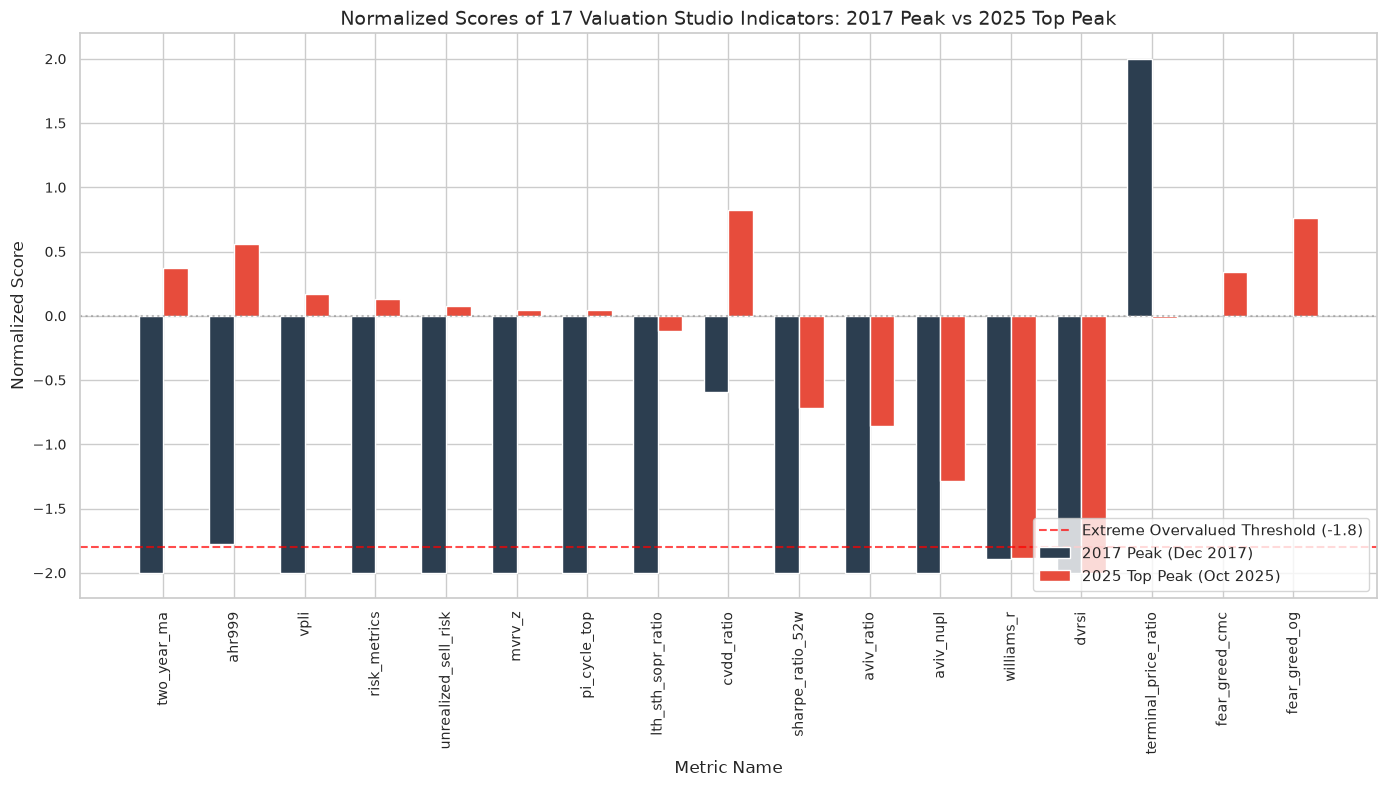

In [7]:
# Visualize the normalized scores at 2017 Peak vs 2025 Top Peak
plt.figure(figsize=(14, 8))
x = np.arange(len(df_compare_indicators))
width = 0.35

plt.bar(x - width/2, df_compare_indicators['2017 Peak'], width, label='2017 Peak (Dec 2017)', color='#2c3e50')
plt.bar(x + width/2, df_compare_indicators['2025 Top Peak'], width, label='2025 Top Peak (Oct 2025)', color='#e74c3c')

plt.axhline(y=-1.8, color='red', linestyle='--', alpha=0.7, label='Extreme Overvalued Threshold (-1.8)')
plt.axhline(y=0.0, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('Metric Name')
plt.ylabel('Normalized Score')
plt.title('Normalized Scores of 17 Valuation Studio Indicators: 2017 Peak vs 2025 Top Peak')
plt.xticks(x, df_compare_indicators.index, rotation=90)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Section 4: Volatility Dampening & Asset Maturation
A key factor behind the failure of longer-term technical/risk indicators to reach extremes is **volatility dampening**. As institutional capital moves in, Bitcoin's annualized volatility has consistently fallen at each successive peak.


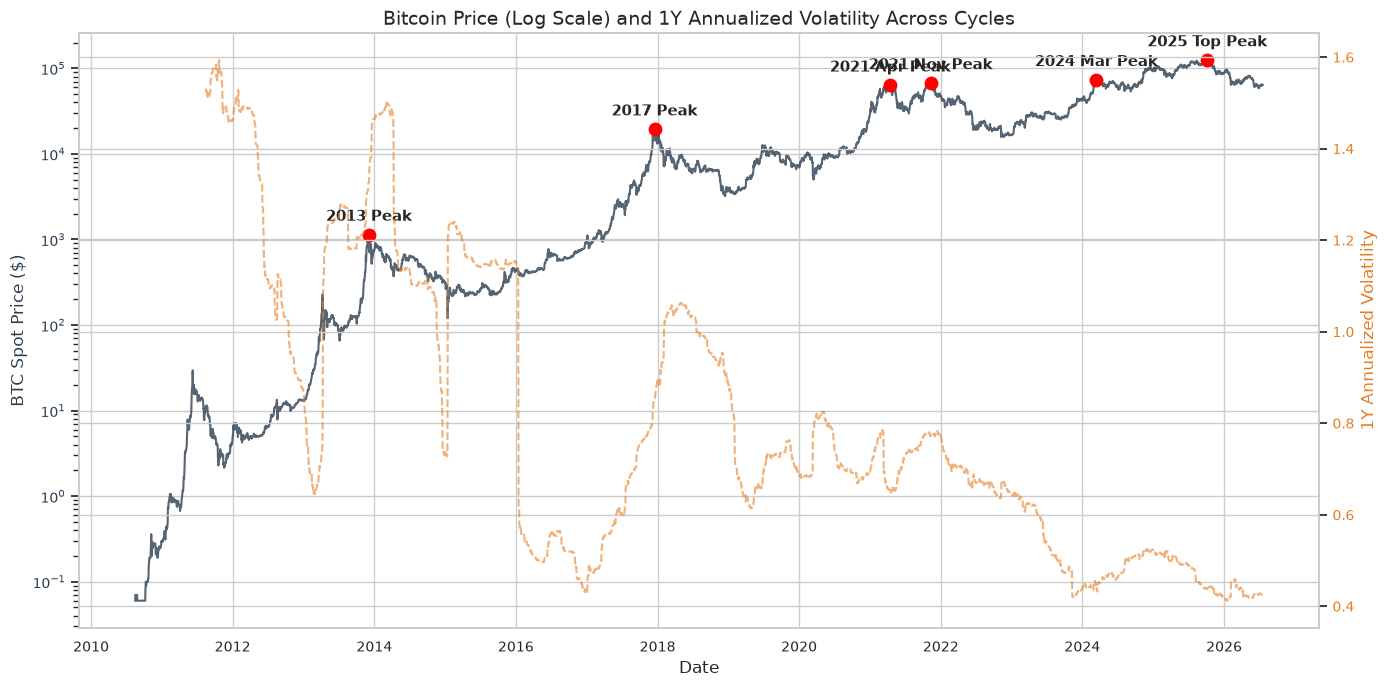

In [8]:
# Plot spot price and rolling 1Y volatility over time
fig, ax1 = plt.subplots(figsize=(14, 7))

color = '#2c3e50'
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Spot Price ($)', color=color)
ax1.plot(onchain.index, onchain['spot_price'], color=color, alpha=0.8, label='BTC Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax2 = ax1.twinx()
color = '#e67e22'
ax2.set_ylabel('1Y Annualized Volatility', color=color)
ax2.plot(onchain.index, onchain['vol_1y'], color=color, alpha=0.6, linestyle='--', label='1Y Ann Volatility')
ax2.tick_params(axis='y', labelcolor=color)

# Add peak markers
for label, p_date in peaks.items():
    if p_date in onchain.index:
        y_val = onchain.loc[p_date, 'spot_price']
        ax1.scatter(p_date, y_val, color='red', s=80, zorder=5)
        ax1.annotate(label, (p_date, y_val), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Bitcoin Price (Log Scale) and 1Y Annualized Volatility Across Cycles')
fig.tight_layout()
plt.show()


## Section 5: Long-Term Holder Illiquidity Shift
The most dramatic difference between historical peaks (2013, 2017) and recent tops (2021, 2025) is the percentage of supply held by **Long-Term Holders (LTHs)**. In 2017, LTHs sold down to 53% of supply. In 2025, they held **77.2%**, meaning the liquid/active market was extremely thin.


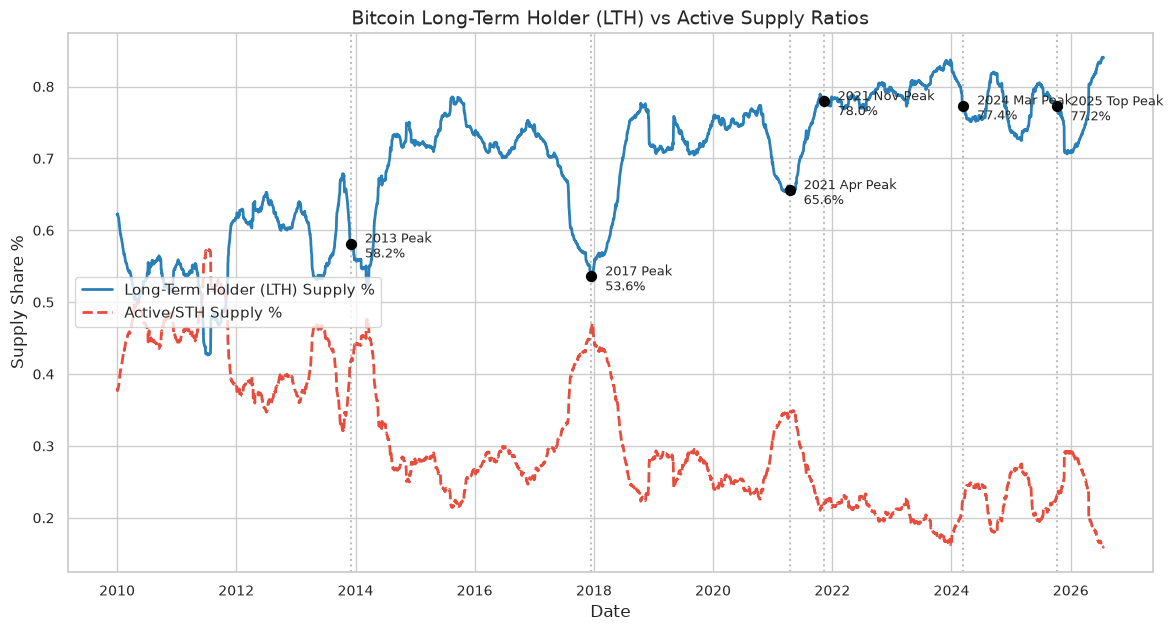

In [9]:
# Plot LTH vs STH Supply Ratios over time
plt.figure(figsize=(14, 7))
plt.plot(onchain.index, onchain['lth_ratio'], color='#2980b9', linewidth=2, label='Long-Term Holder (LTH) Supply %')
plt.plot(onchain.index, onchain['active_ratio'], color='#e74c3c', linewidth=2, linestyle='--', label='Active/STH Supply %')

# Draw peak vertical lines
for label, p_date in peaks.items():
    if p_date in onchain.index:
        lth_val = onchain.loc[p_date, 'lth_ratio']
        plt.axvline(x=p_date, color='gray', linestyle=':', alpha=0.5)
        plt.scatter(p_date, lth_val, color='black', s=50, zorder=5)
        plt.annotate(f"{label}\n{lth_val:.1%}", (p_date, lth_val), textcoords="offset points", xytext=(10,-10), ha='left', fontsize=9)

plt.title('Bitcoin Long-Term Holder (LTH) vs Active Supply Ratios')
plt.xlabel('Date')
plt.ylabel('Supply Share %')
plt.legend(loc='center left')
plt.show()


## Section 6: Realized Price Inflows & MVRV Ceiling Collapse
Realized Price represents the average cost basis of all coins. Institutional inflows (such as ETFs and corporate treasuries) buy coins at high prices, which raises the Realized Price extremely fast.

Because the average cost basis rises so fast during the bull market, the spot price cannot rise far above it in percentage terms. This leads to a **collapse of the MVRV cycle ceiling**.


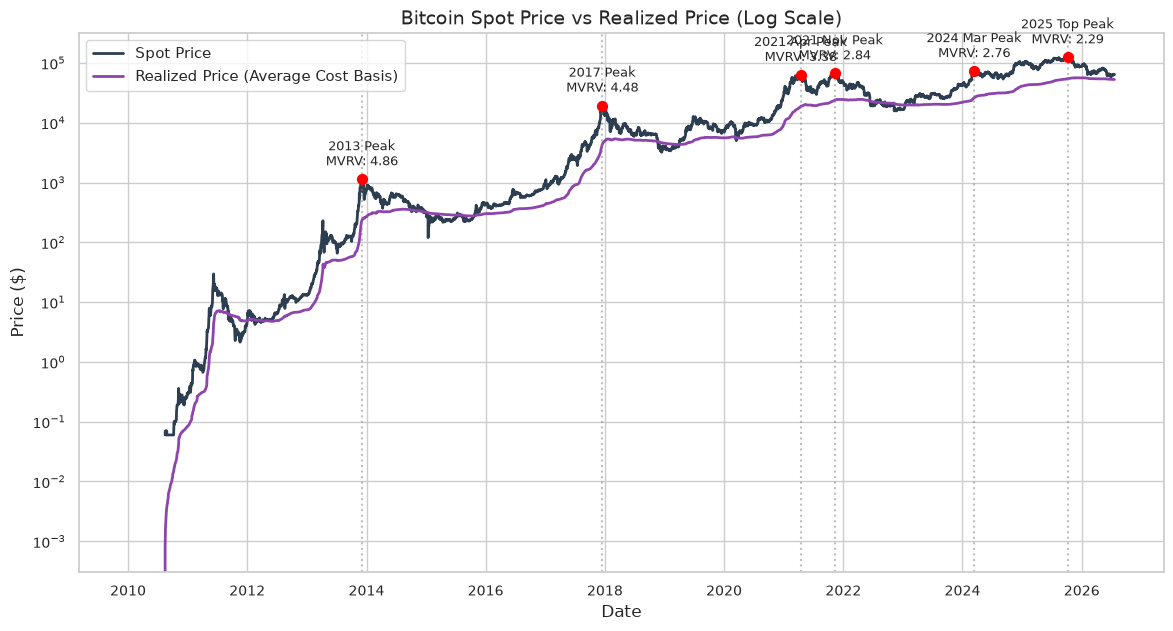

In [10]:
# Plot Spot Price vs Realized Price
plt.figure(figsize=(14, 7))
plt.plot(onchain.index, onchain['spot_price'], color='#2c3e50', linewidth=2, label='Spot Price')
plt.plot(onchain.index, onchain['realized_price'], color='#8e44ad', linewidth=2, label='Realized Price (Average Cost Basis)')

for label, p_date in peaks.items():
    if p_date in onchain.index:
        spot_val = onchain.loc[p_date, 'spot_price']
        mvrv_val = onchain.loc[p_date, 'mvrv']
        plt.axvline(x=p_date, color='gray', linestyle=':', alpha=0.5)
        plt.scatter(p_date, spot_val, color='red', s=50, zorder=5)
        plt.annotate(f"{label}\nMVRV: {mvrv_val:.2f}", (p_date, spot_val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Bitcoin Spot Price vs Realized Price (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.yscale('log')
plt.legend(loc='upper left')
plt.show()


## Section 7: Institutional Illiquidity Premium (IIP) - Shock vs New Normal
In 2021, the sudden transition to high LTH holdings was a **deviation/shock** from the historical mean, which triggered the Institutional Illiquidity Premium (IIP) Penalty.

However, by 2025, high illiquidity has lasted for 4 years and became the **new baseline**. Thus, the rolling 4Y average of the illiquidity factor caught up to the spot values, resulting in an IIP Penalty of **0.00**.


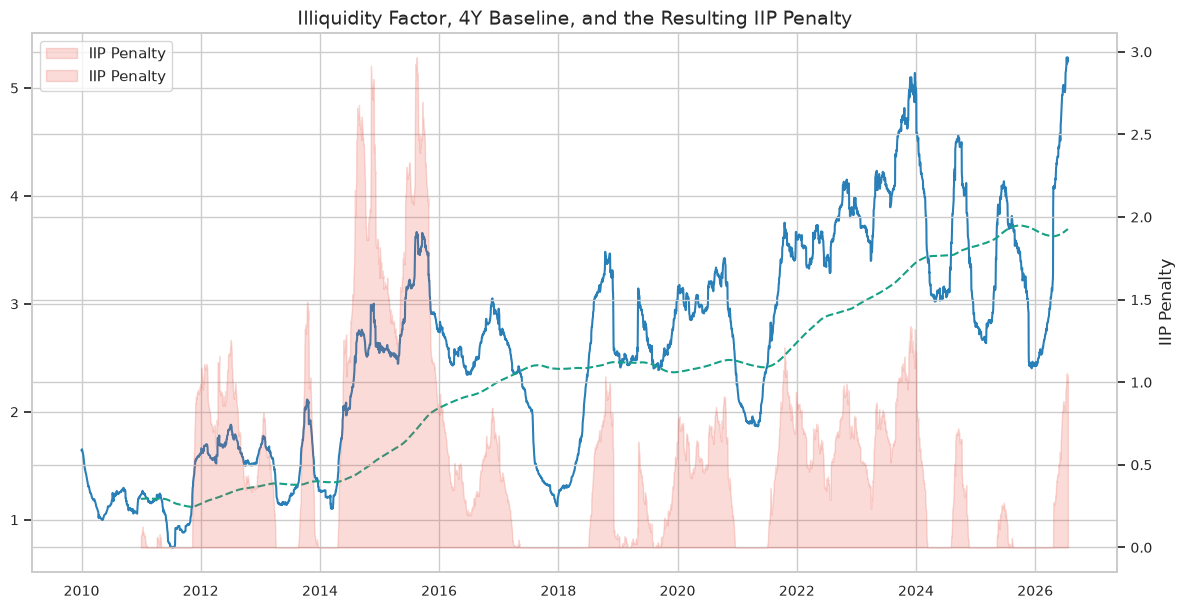

In [11]:
# Plot Illiquidity Factor and its 4Y Rolling Mean
plt.figure(figsize=(14, 7))
plt.plot(onchain.index, onchain['illiquidity_factor'], color='#2980b9', label='Illiquidity Factor (LTH / Active)')
plt.plot(onchain.index, onchain['illiquidity_4y_mean'], color='#16a085', linestyle='--', label='4Y Rolling Mean (Baseline)')

ax_twin = plt.twinx()
ax_twin.fill_between(onchain.index, onchain['iip_penalty'], color='#e74c3c', alpha=0.2, label='IIP Penalty')
ax_twin.set_ylabel('IIP Penalty')

plt.title('Illiquidity Factor, 4Y Baseline, and the Resulting IIP Penalty')
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()


## Section 8: Indicator Cross-Correlation & Cycle Similarity
We calculate the Spearman Rank Correlation of the normalized indicators over history to check how closely they move together. We also show how the Composite Valuation Index behaved across cycles.


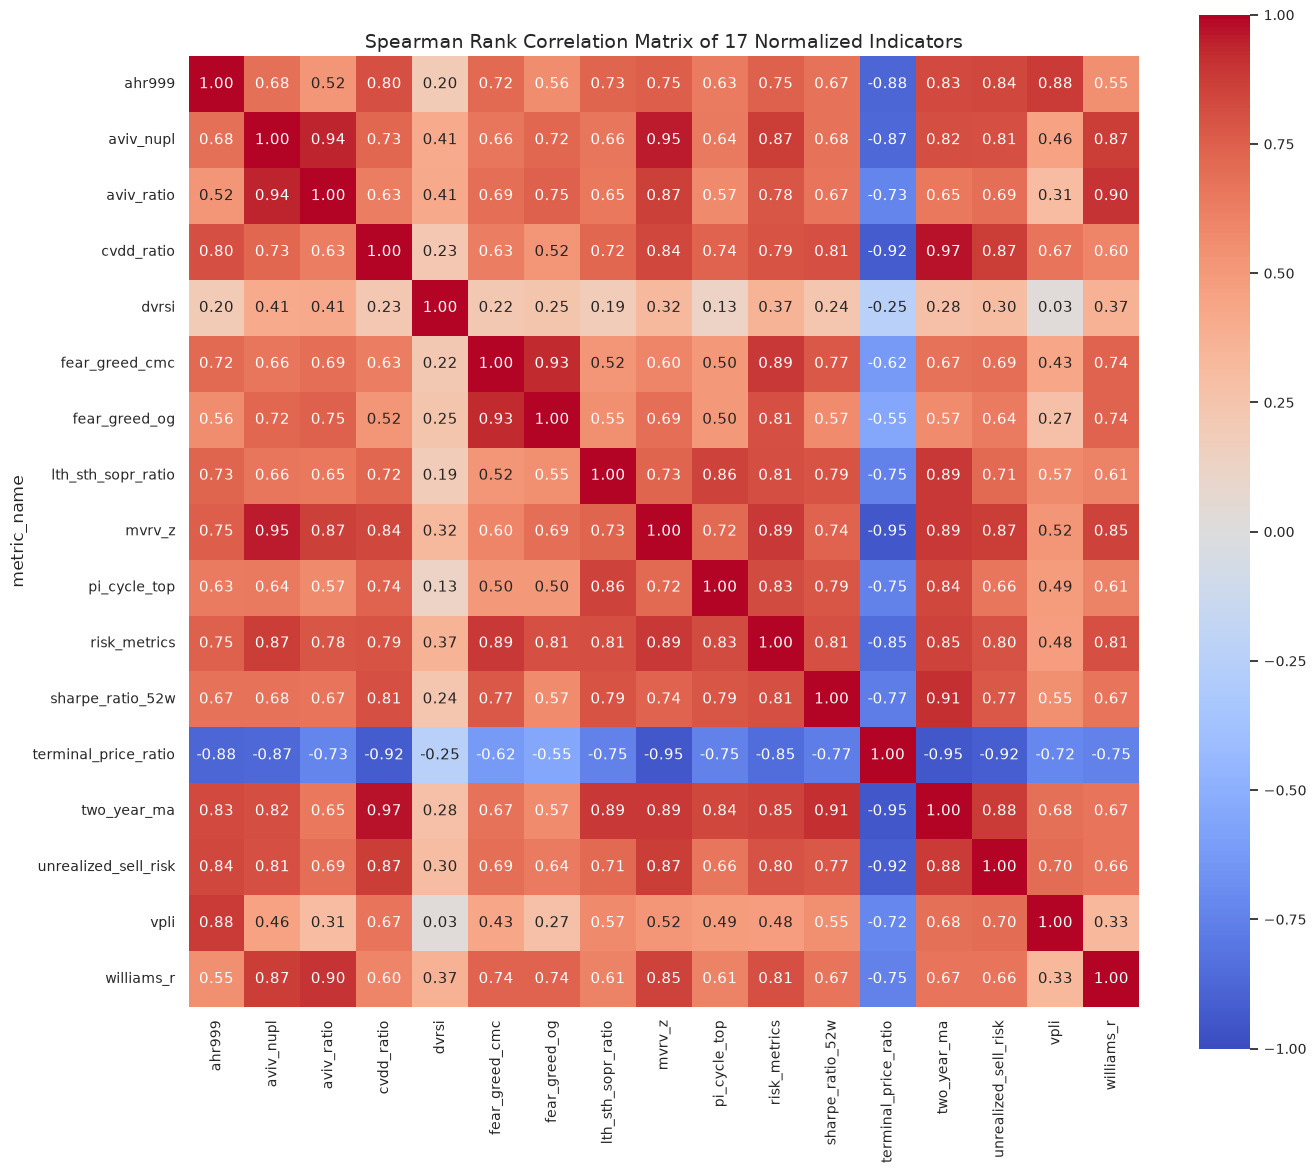

In [12]:
# Load indicator correlation matrix
df_corr = pd.read_csv('indicators_correlation.csv')
if 'metric_name' in df_corr.columns:
    df_corr.set_index('metric_name', inplace=True)
elif 'Unnamed: 0' in df_corr.columns:
    df_corr.set_index('Unnamed: 0', inplace=True)

# Plot Correlation Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0, square=True)
plt.title('Spearman Rank Correlation Matrix of 17 Normalized Indicators')
plt.tight_layout()
plt.show()


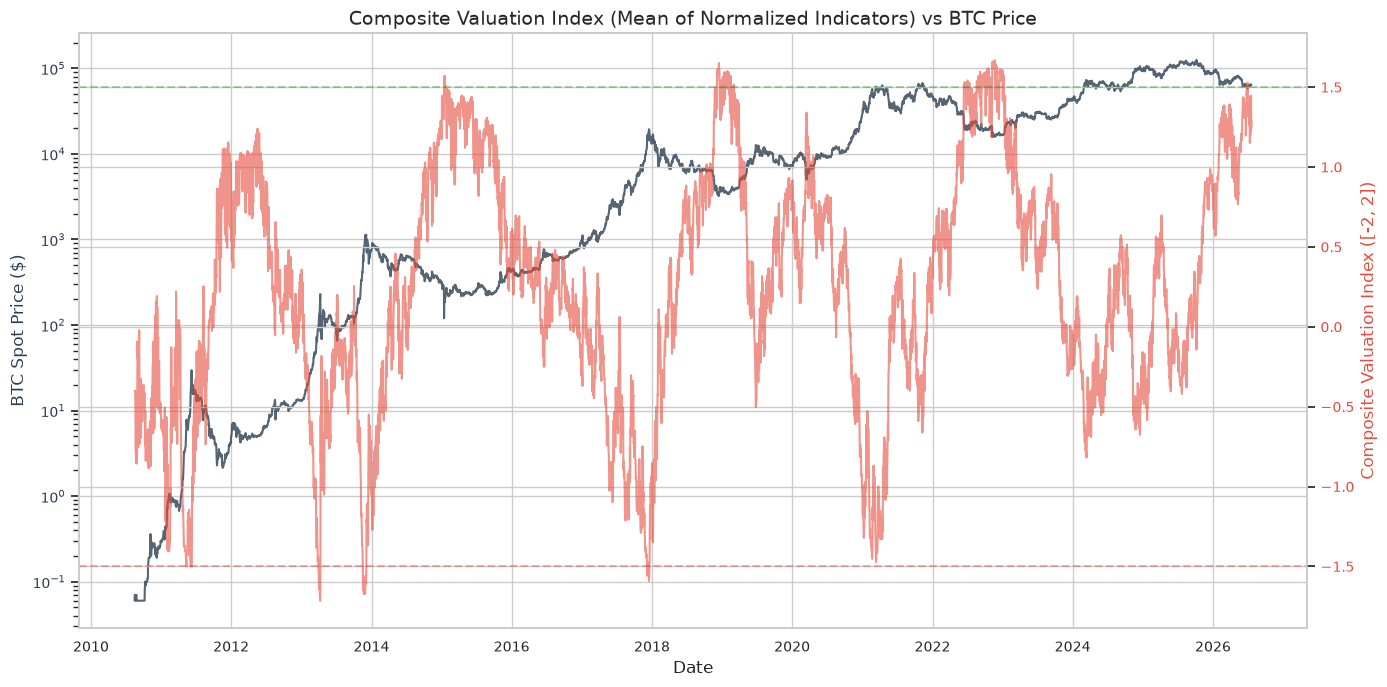

In [13]:
# Load composite vs price
df_comp_price = pd.read_csv('composite_vs_price.csv')
df_comp_price['date'] = pd.to_datetime(df_comp_price['date'], format='mixed', utc=True)
df_comp_price.set_index('date', inplace=True)

# Plot Composite Index vs Price
fig, ax1 = plt.subplots(figsize=(14, 7))

color = '#2c3e50'
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Spot Price ($)', color=color)
ax1.plot(df_comp_price.index, df_comp_price['price'], color=color, alpha=0.8, label='BTC Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax2 = ax1.twinx()
color = '#e74c3c'
ax2.set_ylabel('Composite Valuation Index ([-2, 2])', color=color)
ax2.plot(df_comp_price.index, df_comp_price['composite'], color=color, alpha=0.6, label='Composite Index')
ax2.tick_params(axis='y', labelcolor=color)

# Overvalued/Undervalued fills
ax2.axhline(y=-1.5, color='red', linestyle='--', alpha=0.3)
ax2.axhline(y=1.5, color='green', linestyle='--', alpha=0.3)

plt.title('Composite Valuation Index (Mean of Normalized Indicators) vs BTC Price')
fig.tight_layout()
plt.show()


## Section 9: Skeptic's Corner & Quantitative Recommendations
As quantitative researchers, we must view our results with deep skepticism:

1. **Why the traditional composite failed in 2025:**
   - **Regime Blindness:** Normalizing to historical bounds assuming stationary distributions (e.g. MVRV > 4 is a top) fails when the underlying distribution undergoes a regime shift due to structural changes (ETF inflows).
   - **Baseline Drift in IIP:** The IIP modifier, while effective in 2021, failed in 2025 because it is relative to a rolling 4Y average. A permanent regime shift to illiquidity eventually shifts the rolling 4Y average to match the spot level, neutralizing the relative penalty.

2. **Alternative Strategies & Recommendations:**
   - **Vol-Adjusted Thresholds:** We should scale the overvalued/undervalued thresholds dynamically using rolling volatility. Since volatility has dropped by 50%, the threshold for "bubble risk" should drop from MVRV of 4.5 to MVRV of 2.2-2.5.
   - **Illiquidity-Adjusted Z-Scores:** Rather than using raw MVRV, we should normalize MVRV using a Z-score where the mean and standard deviation are adjusted for the LTH supply ratio:
     $$MVRV_{adj} = MVRV 	imes (1 + \lambda 	imes LTH\_Ratio)$$
     This would structurally boost valuation scores in highly illiquid regimes.

---
*End of Report.*
